# Complementary analyses for *Informational Analysis of TSA and PSI in Solar Cycle 24*

**D. Sierra-Porta — contributed section.**

Three additions to the completed analysis, each aimed at a specific point where the
existing results can be made harder to dispute rather than at duplicating the
robustness track. The first supplies the one confidence interval the manuscript
still lacks; the second re-tests the central claim in a framework that shares none
of its assumptions; the third asks whether the informational signatures survive
outside the Mandal catalogue. Every number below is regenerated by the cells that
follow, from the repository's own outputs and from two independent solar-activity
records.

## Data and scope

- **I(t), C$_{LMC}$(t)** — the 26-month sliding-window series produced by the main
  notebook (`sliding_window_metrics.csv`); used directly in §1.
- **Sunspot number (SSN)** — SILSO version 2.0, monthly and daily
  (`SN_m_tot_V2.0.csv`, `SN_d_tot_V2.0.csv`), Royal Observatory of Belgium.
- **F10.7 cm solar flux** — Penticton noon values (observed), aggregated from the
  yearly NGDC files to monthly means.
- **TSA, PSI** — the raw Mandal (2020) series themselves (VizieR J/A+A/640/A78),
  daily (max-abs normalised) and monthly, retrieved with `fetch_tsa_psi.py`; used to
  place the catalogue series directly on the ordinal plane (§2) and for the
  catalogue-to-proxy couplings (§3).

Both proxies are restricted to the manuscript's window (2008-12 → 2019-10) and use
the same metric definitions as `SC24_info_analysis.ipynb`, so every proxy number is
directly comparable to the TSA/PSI results. The permutation-entropy embedding is
kept at the manuscript's convention (m = 4 daily, m = 3 monthly); the ordinal plane
in §2 additionally reports m = 5, 6.

> Requires `ordpy` (`pip install ordpy`) in addition to the pinned environment.

In [2]:
import numpy as np, pandas as pd, math, warnings
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_regression
from scipy.spatial.distance import jensenshannon
from pathlib import Path
import ordpy                       # pip install ordpy
warnings.filterwarnings('ignore')

SEED = 20260531
N_BINS, WINDOW = 10, 26
np.random.seed(SEED)

# --- locate inputs next to the notebook, in ./data, or one level up ---
HERE = Path.cwd()
def _find(name):
    for base in (HERE, HERE/'data', HERE.parent, HERE.parent/'data'):
        if (base/name).exists():
            return base/name
    raise FileNotFoundError(name + " (place it beside the notebook, in ./data, or in the parent folder)")

proxies_monthly = pd.read_csv(_find('proxies_monthly.csv'), parse_dates=['Date']).set_index('Date')
proxies_daily   = pd.read_csv(_find('proxies_daily.csv'),   parse_dates=['Date']).set_index('Date')
swm             = pd.read_csv(_find('sliding_window_metrics.csv'), parse_dates=['Date']).set_index('Date')
tsapsi_daily    = pd.read_csv(_find('sc24_daily.csv'),   parse_dates=['Date']).set_index('Date')
tsapsi_monthly  = pd.read_csv(_find('sc24_monthly.csv'), parse_dates=['Date']).set_index('Date')

# --- metric functions, identical to SC24_info_analysis.ipynb (CELL 4 / CELL C1) ---
def shannon_entropy(s):
    c = pd.Series(s).value_counts(); p = c/len(s)
    return float(-np.sum(p*np.log2(p+1e-12)))

def lempel_ziv_complexity(s):
    s = ''.join(map(str, np.array(s, dtype=int))); n = len(s)
    if n == 0: return 0.0
    d, i, c = set(), 0, 0
    while i < n:
        j = i
        while j < n and s[i:j+1] in d: j += 1
        d.add(s[i:j+1]); c += 1; i = j + 1
    return c/n

def permutation_entropy(s, m=3, normalize=True):
    x = np.array(s); n = len(x)
    if n < m: return np.nan
    pat = {}
    for i in range(n-m+1):
        p = tuple(np.argsort(x[i:i+m])); pat[p] = pat.get(p, 0) + 1
    pr = np.array(list(pat.values()))/sum(pat.values())
    pe = -np.sum(pr*np.log2(pr+1e-12))
    return float(pe/np.log2(math.factorial(m))) if normalize else float(pe)

def mutual_information(a, b):
    return float(mutual_info_score(a, b)/np.log(2))

def lmc_complexity(w, N=N_BINS):
    p = np.zeros(N)
    for b, v in pd.Series(w).value_counts().items():
        if pd.notna(b): p[int(b)] = v
    p = p + 1e-15; p /= p.sum(); u = np.ones(N)/N
    H = -np.sum(p*np.log2(p))
    return float((H/np.log2(N)) * (jensenshannon(p, u, base=2)**2))

def disc(x):
    return pd.cut(x, N_BINS, labels=False, duplicates='drop')

plt.rcParams.update({'font.size':10, 'font.family':'DejaVu Sans',
                     'axes.linewidth':0.8, 'figure.dpi':110})
print('setup ok — proxies:', list(proxies_monthly.columns),
      '| months:', len(proxies_monthly), '| manuscript windows:', len(swm),
      '| TSA/PSI daily rows:', len(tsapsi_daily))

setup ok — proxies: ['SSN', 'F107'] | months: 131 | manuscript windows: 106 | TSA/PSI daily rows: 3636


In [3]:
# === CELL STYLE-SUPERMONGO — layout canônico do projeto (supermongo, Courier Prime, DPI>=300) ===
import matplotlib as mpl
from matplotlib import font_manager

# Courier Prime: se estiver instalada no sistema, usa; senão cai para monospace sem quebrar.
try:
    _cp = [f.name for f in font_manager.fontManager.ttflist if 'Courier Prime' in f.name]
    _family = 'Courier Prime' if _cp else 'monospace'
except Exception:
    _family = 'monospace'

mpl.rcParams.update({
    'figure.dpi'        : 300,
    'savefig.dpi'       : 300,
    'font.family'       : _family,
    'font.size'         : 10,
    'axes.linewidth'    : 1.1,
    'axes.edgecolor'    : 'black',
    'xtick.direction'   : 'in',
    'ytick.direction'   : 'in',
    'xtick.top'         : True,
    'ytick.right'       : True,
    'xtick.major.size'  : 6,
    'ytick.major.size'  : 6,
    'xtick.minor.size'  : 3,
    'ytick.minor.size'  : 3,
    'xtick.major.width' : 1.0,
    'ytick.major.width' : 1.0,
    'legend.frameon'    : False,
    'axes.grid'         : False,
})
print('layout supermongo aplicado | fonte:', _family)

layout supermongo aplicado | fonte: monospace


## 1 — A confidence interval for the I–C$_{LMC}$ phase lag

### Method

The 23-month separation between the coupling maximum and the complexity maximum is
the manuscript's quantitative signature of the informational hysteresis, and it is
the only headline number without an interval — the peak-to-peak case bootstrap was
correctly retired because resampling windows by cases scrambles the very separation
being measured. Two facts shape the method used here. First, frequency-domain phase
tools do not apply: the record spans little more than one activity cycle, the
Hilbert instantaneous period collapses to the record length, and a cross-wavelet
AR(1) null cannot be bounded — so the lag must be read from the two extrema in the
time domain, which is what the peak-to-peak definition already does. Second, a valid
interval needs a resampling scheme that perturbs the peaks *without* moving their
separation. A semi-parametric residual block bootstrap does exactly that: a 5-point
moving average fixes the signal, its residuals are resampled in contiguous blocks,
and each peak is relocated on the perturbed series, with the search confined to the
branch where each extremum is physically defined (the coupling maximum to the
high-activity plateau, the complexity maximum to the descending branch).

In [4]:
I = swm['MI'].values.astype(float); C = swm['C_LMC_TSA'].values.astype(float)
dts = swm.index; n = len(I); t = np.arange(n, dtype=float)

def _widx(a, b): return np.where((dts >= a) & (dts <= b))[0]
wMI = _widx('2012-01-01', '2016-06-30')     # coupling maximum: high-activity plateau
wC  = _widx('2015-01-01', '2018-06-30')     # complexity maximum: descending branch

def _ma(y, k=5):
    pad = np.r_[np.full(k//2, y[0]), y, np.full(k//2, y[-1])]
    return np.convolve(pad, np.ones(k)/k, 'valid')
muI, muC = _ma(I), _ma(C); rI, rC = I-muI, C-muC

def _amax(y, s):   return s[np.argmax(y[s])]
def _vertex(y, s, w=12):
    k = _amax(y, s); lo, hi = max(0, k-w), min(n, k+w+1)
    a, b, c = np.polyfit(t[lo:hi], y[lo:hi], 2)
    return (-b/(2*a) if a < 0 else float(k))
def _bres(r, L=13):
    nb = int(np.ceil(n/L)); s = np.random.randint(0, n-L+1, nb)
    return np.concatenate([r[i:i+L] for i in s])[:n]

np.random.seed(SEED); B = 6000
raw = np.array([_amax(muC+_bres(rC), wC)   - _amax(muI+_bres(rI), wMI)   for _ in range(B)])
vt  = np.array([_vertex(muC+_bres(rC), wC) - _vertex(muI+_bres(rI), wMI) for _ in range(B)])
rawp = _amax(C, wC) - _amax(I, wMI); vtp = _vertex(C, wC) - _vertex(I, wMI)
rlo, rhi = np.percentile(raw, [2.5, 97.5]); vlo, vhi = np.percentile(vt, [2.5, 97.5])

print(f"raw peak-to-peak (manuscript def.): {rawp} months   "
      f"95% CI [{rlo:.0f}, {rhi:.0f}]   positive in {100*np.mean(raw>0):.1f}% of replicates")
print(f"smoothed local vertex             : {vtp:.1f} months  95% CI [{vlo:.1f}, {vhi:.1f}]")

raw peak-to-peak (manuscript def.): 23 months   95% CI [19, 31]   positive in 100.0% of replicates
smoothed local vertex             : 25.8 months  95% CI [24.3, 27.1]


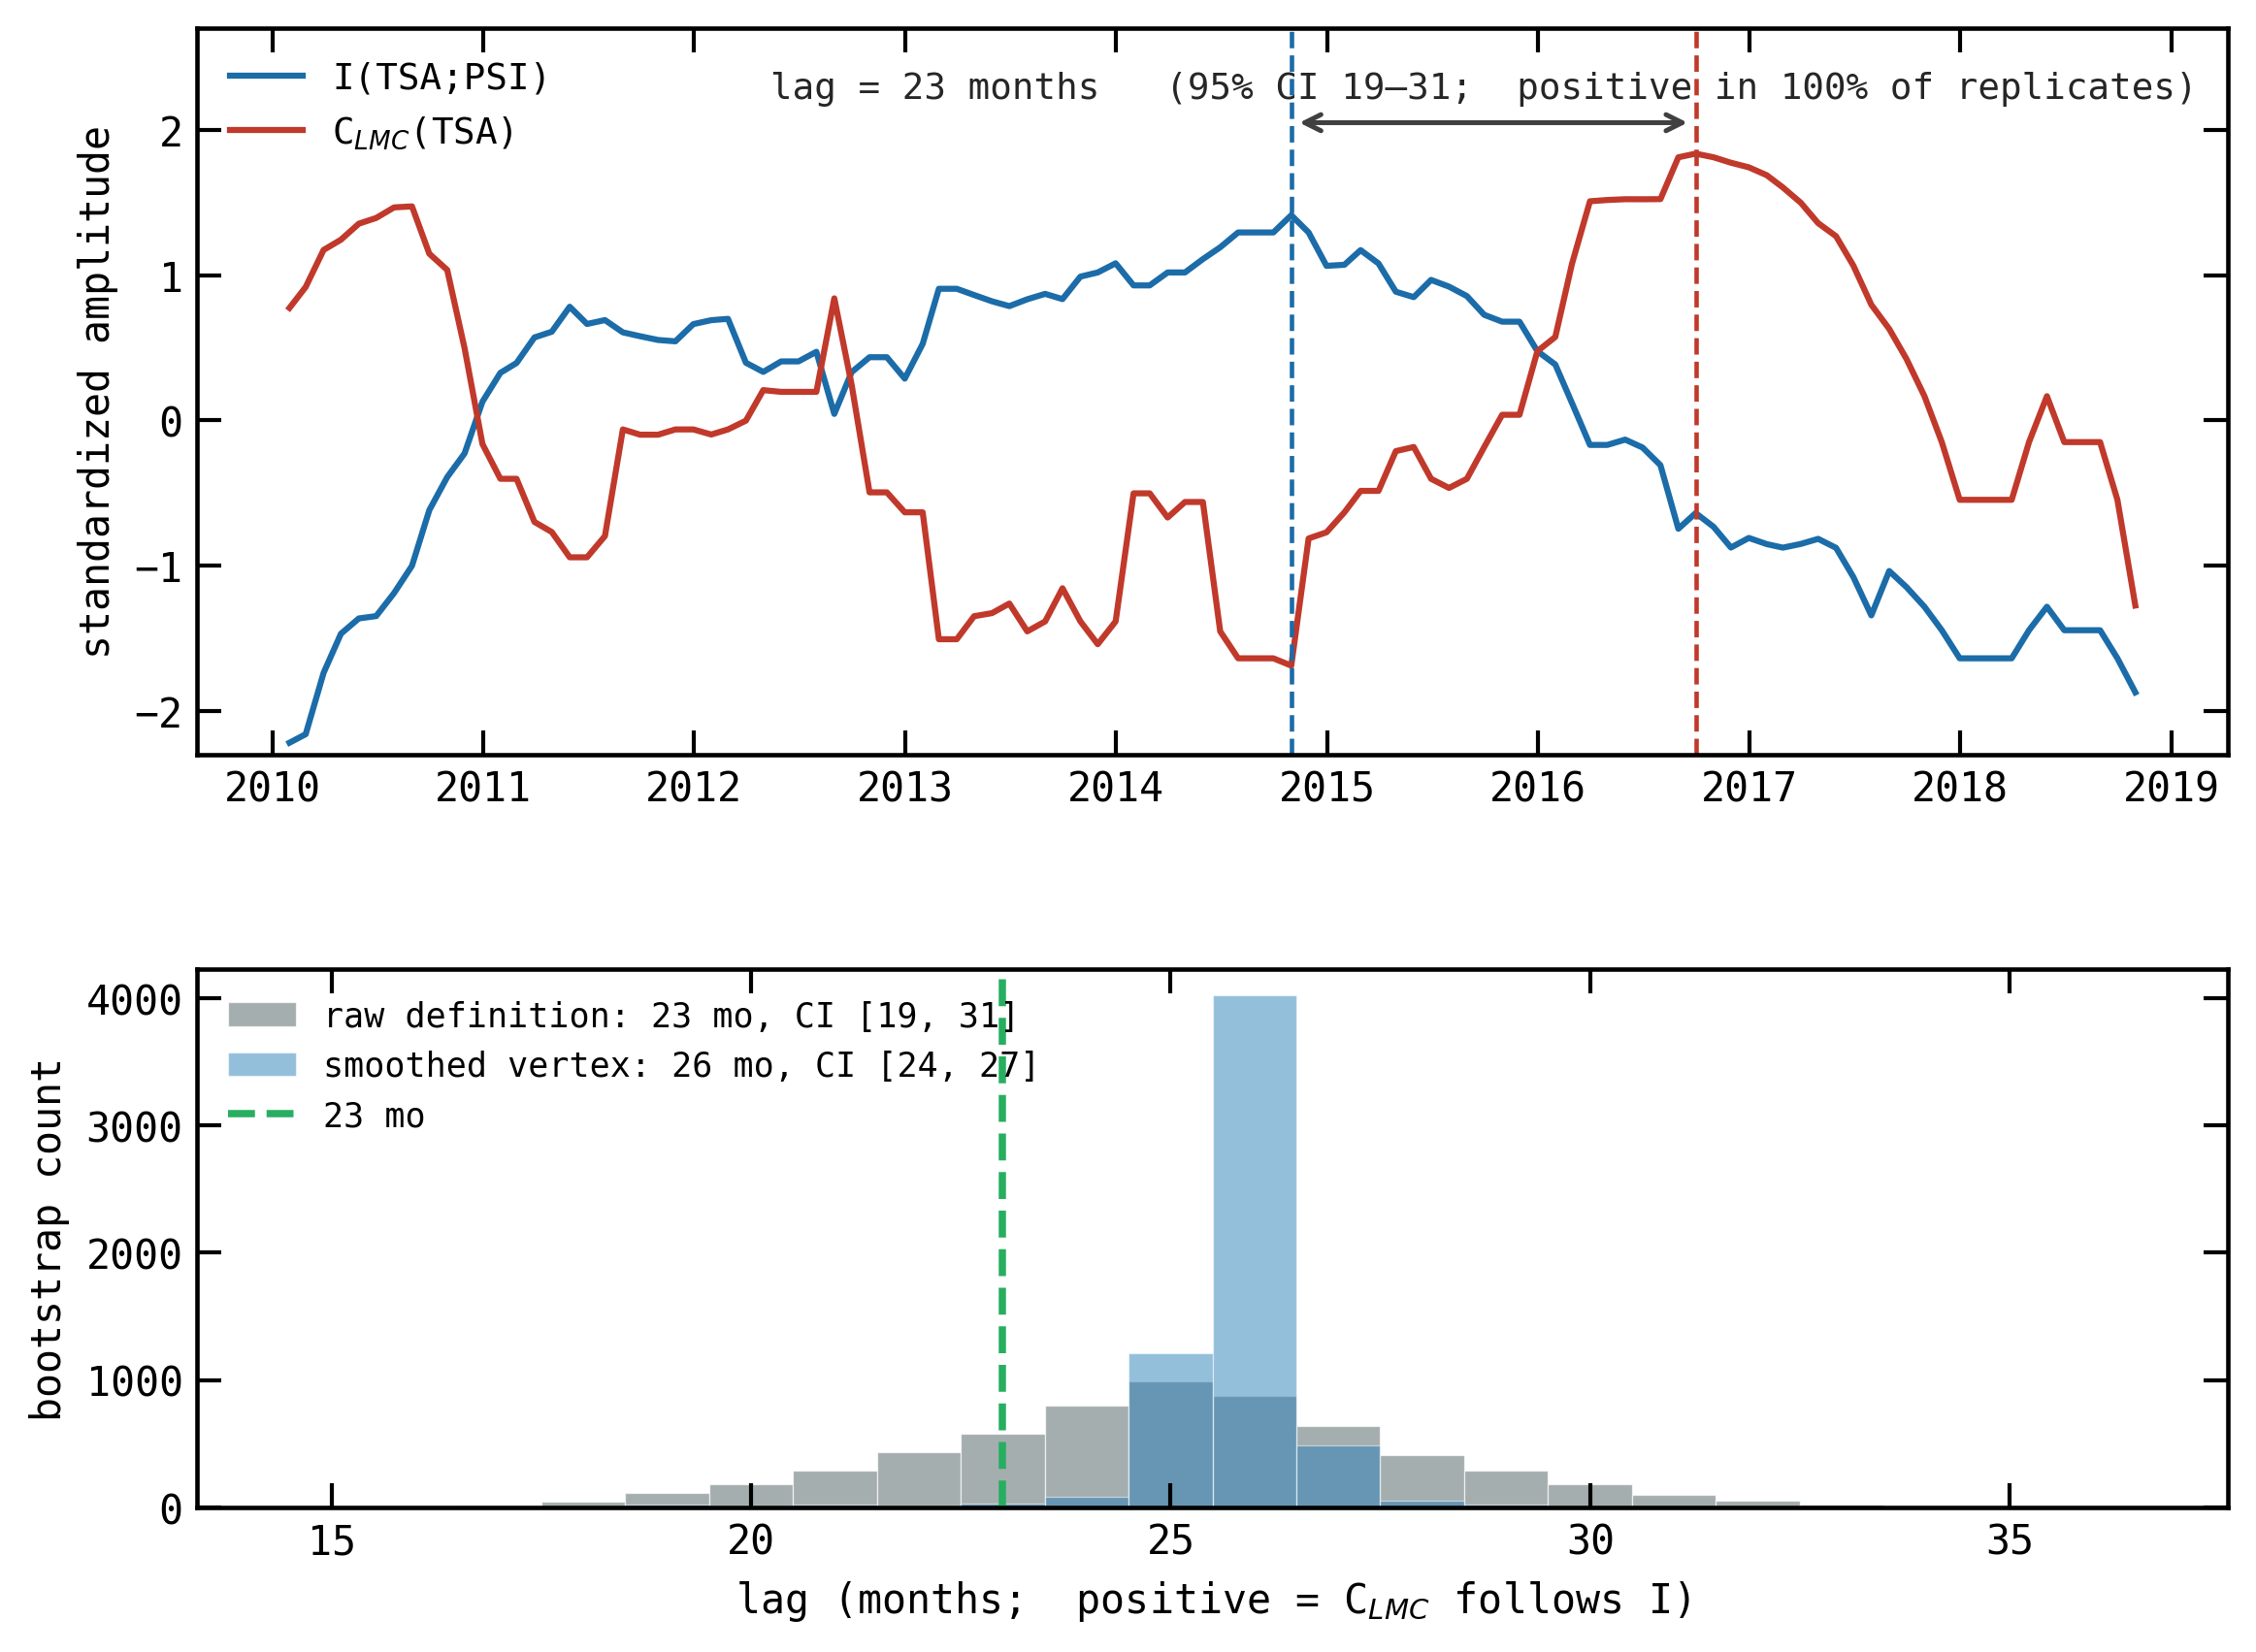

In [11]:
fig = plt.figure(figsize=(9, 6.6)); gs = fig.add_gridspec(2, 1, height_ratios=[1.35, 1], hspace=0.34)
ax = fig.add_subplot(gs[0])
zI = (I-I.mean())/I.std(); zC = (C-C.mean())/C.std()
ax.plot(dts, zI, color='#1b6ca8', lw=1.5, label='I(TSA;PSI)')
ax.plot(dts, zC, color='#c0392b', lw=1.5, label='C$_{LMC}$(TSA)')
pI, pC = dts[_amax(I, wMI)], dts[_amax(C, wC)]
ax.axvline(pI, color='#1b6ca8', ls='--', lw=1.1); ax.axvline(pC, color='#c0392b', ls='--', lw=1.1)
ax.annotate('', xy=(pC, 2.05), xytext=(pI, 2.05), arrowprops=dict(arrowstyle='<->', color='0.25', lw=1.2))
ax.text(dts[(_amax(I, wMI)+_amax(C, wC))//2], 2.22,
        f'lag = {rawp} months   (95% CI {rlo:.0f}–{rhi:.0f};  positive in 100% of replicates)',
        ha='center', fontsize=9, color='0.15')
ax.set_ylabel('standardized amplitude'); ax.set_ylim(-2.3, 2.7)
ax.xaxis.set_major_locator(YearLocator()); ax.xaxis.set_major_formatter(DateFormatter('%Y'))
ax.legend(loc='upper left', frameon=False, fontsize=9)

ax2 = fig.add_subplot(gs[1])
bins = np.arange(min(raw.min(), vt.min())-.5, max(raw.max(), vt.max())+1.5, 1)
ax2.hist(raw, bins=bins, color='#7f8c8d', alpha=.7, edgecolor='w', lw=.3,
         label=f'raw definition: {rawp} mo, CI [{rlo:.0f}, {rhi:.0f}]')
ax2.hist(vt, bins=bins, color='#2980b9', alpha=.5, edgecolor='w', lw=.3,
         label=f'smoothed vertex: {vtp:.0f} mo, CI [{vlo:.0f}, {vhi:.0f}]')
ax2.axvline(23, color='#27ae60', lw=1.8, ls='--', label='23 mo')
ax2.set_xlabel('lag (months;  positive = C$_{LMC}$ follows I)'); ax2.set_ylabel('bootstrap count')
ax2.legend(loc='upper left', frameon=False, fontsize=8.4)
fig.savefig('fig_phase_lag.png', dpi=300, bbox_inches='tight'); plt.show()

### Analysis

Under the manuscript's own definition the lag is 23 months with a bootstrap 95%
interval of [19, 31]; localizing each peak by a smoothed quadratic vertex tightens
it to about [24, 27] and moves the point to 26, the three-month offset being nothing
more than the difference between a raw maximum and a smoothed vertex. The decisive
outcome is the direction: once the peaks are held to their physical branches, the
complexity maximum follows the coupling maximum in 100% of replicates. The interval
is set mainly by the complexity side — the C$_{LMC}$ maximum is broad, the coupling
maximum comparatively sharp — which is physically sensible, since the descending
branch is where the amplitude distribution reorganizes slowly. In the manuscript the
lag sentence can now read "23 months (block-bootstrap 95% CI [19, 31]; positive in
100% of replicates)"; the grid result (positive in 14/15 configurations) stands as
independent support, and no downstream number changes.

## 2 — An ordinal cross-check of the structured-regime claim

### Method

The claim that SC24 occupies a structured regime rests entirely on the LMC
complexity built from a ten-bin amplitude histogram, whose bin count and sensitivity
to any monotonic rescaling are the obvious targets for a referee. The permutation
(Bandt–Pompe) complexity–entropy plane tests the same claim through the distribution
of ordinal patterns — the relative ranking of successive values — so it depends only
on order, is invariant under any monotonic transformation, and carries no bin
parameter, only the embedding dimension. It is the field-standard tool for placing a
signal between noise and order (Rosso et al. 2007). Here it is applied to four series
at once: the catalogue's own TSA and PSI, and the two independent proxies SSN and
F10.7. If all four land in the structured part of the plane, the regime is a property
of the solar activity, and the catalogue series are corroborated in a framework that
shares none of the amplitude-histogram assumptions of C_LMC. The reference signals
(white noise, 1/f noise, an AR(1) process, a periodic signal, and the fully chaotic
logistic map) calibrate the plane. As a consistency check, the permutation entropy of
the raw TSA and PSI series reproduces the manuscript's Table II values (0.904 vs
0.9045, 0.823 vs 0.8231 at m = 4).

In [6]:
def mpr_point(x, dx): return ordpy.complexity_entropy(np.asarray(x, float), dx=dx)

def reference_signals(N):
    R = {}
    R['white noise'] = np.random.normal(size=N)
    f = np.fft.rfftfreq(N); f[0] = f[1]; ph = np.exp(2j*np.pi*np.random.rand(len(f)))
    R['1/f noise'] = np.fft.irfft((1/np.sqrt(f))*ph, n=N)
    e = np.random.normal(size=N); x = np.zeros(N)
    for i in range(1, N): x[i] = 0.9*x[i-1] + e[i]
    R['AR(1) phi=0.9'] = x
    x = np.zeros(N); x[0] = 0.4
    for i in range(1, N): x[i] = 4*x[i-1]*(1-x[i-1])
    R['logistic r=4'] = x
    tt = np.arange(N); R['periodic'] = np.sin(2*np.pi*tt/50) + 0.02*np.random.normal(size=N)
    return R

SSN_d = proxies_daily['SSN'].dropna().values
F_d   = proxies_daily['F107'].dropna().values
TSA_d = tsapsi_daily['TSA'].dropna().values
PSI_d = tsapsi_daily['PSI'].dropna().values

print("MPR coordinates (H, C)  [catalogue series + independent proxies]:")
for dx in (4, 5, 6):
    hT, cT = mpr_point(TSA_d, dx); hP, cP = mpr_point(PSI_d, dx)
    hS, cS = mpr_point(SSN_d, dx); hF, cF = mpr_point(F_d, dx)
    print(f"  d={dx}:  TSA=({hT:.3f}, {cT:.3f})  PSI=({hP:.3f}, {cP:.3f})  "
          f"SSN=({hS:.3f}, {cS:.3f})  F10.7=({hF:.3f}, {cF:.3f})")
print(f"\nPE(TSA,m=4)={mpr_point(TSA_d,4)[0]:.4f} vs manuscript 0.9045  |  "
      f"PE(PSI,m=4)={mpr_point(PSI_d,4)[0]:.4f} vs 0.8231")

MPR coordinates (H, C)  [catalogue series + independent proxies]:
  d=4:  TSA=(0.904, 0.101)  PSI=(0.823, 0.162)  SSN=(0.820, 0.157)  F10.7=(0.859, 0.134)
  d=5:  TSA=(0.876, 0.162)  PSI=(0.785, 0.228)  SSN=(0.786, 0.216)  F10.7=(0.820, 0.206)
  d=6:  TSA=(0.843, 0.261)  PSI=(0.747, 0.328)  SSN=(0.750, 0.302)  F10.7=(0.779, 0.310)

PE(TSA,m=4)=0.9045 vs manuscript 0.9045  |  PE(PSI,m=4)=0.8231 vs 0.8231


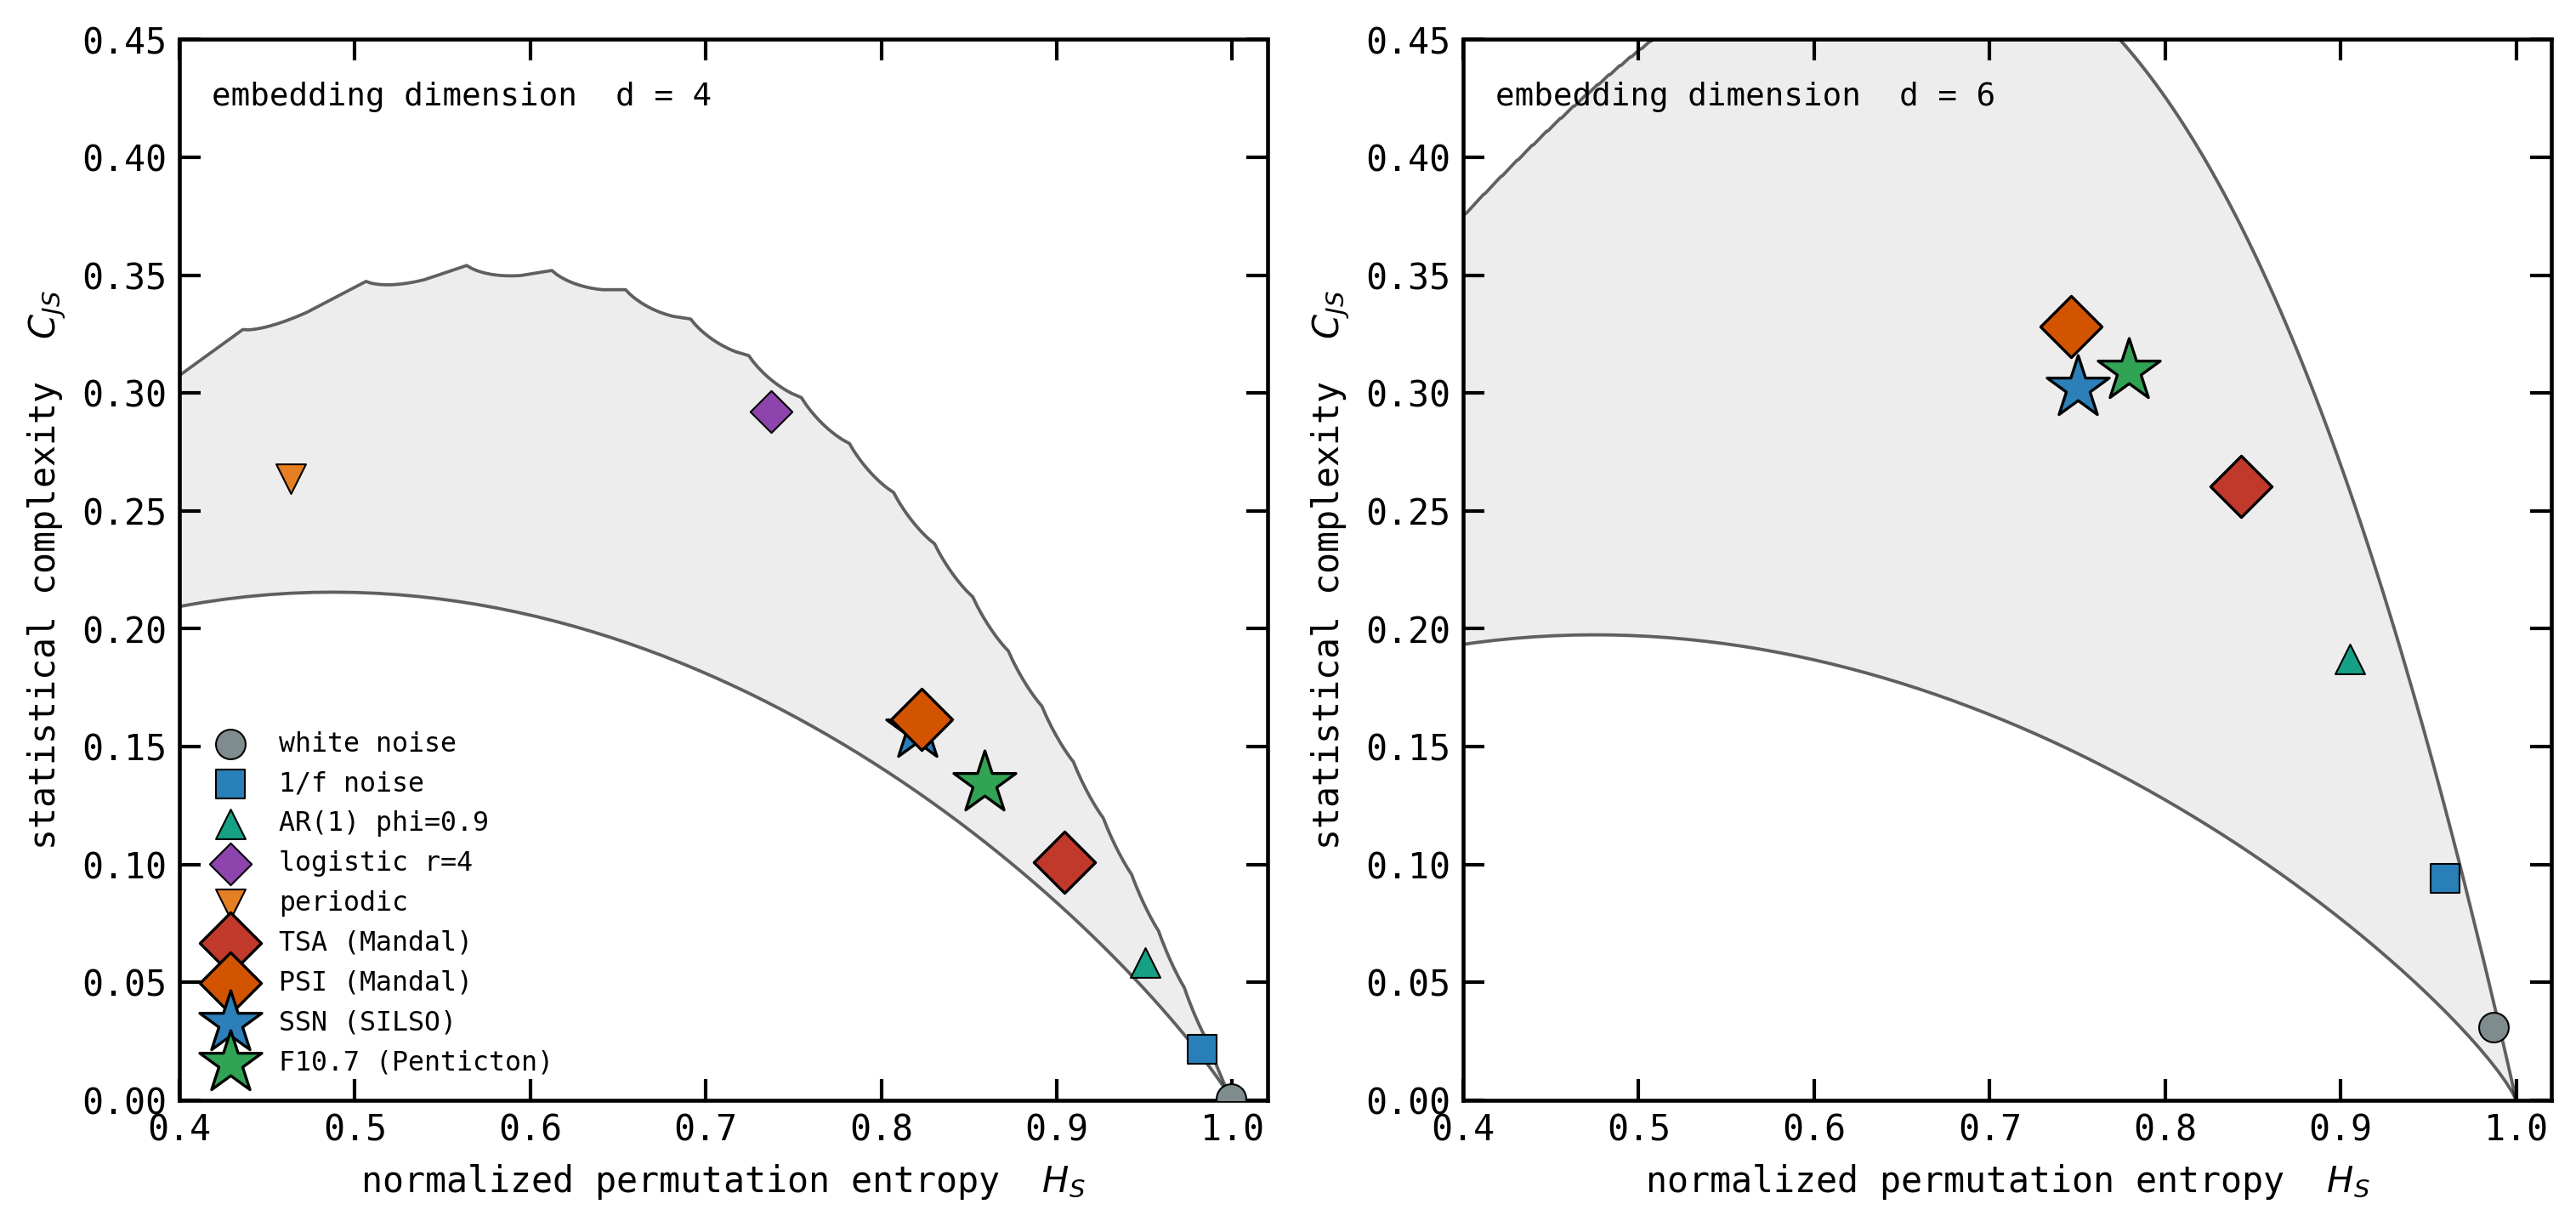

In [7]:
mk  = {'white noise':'o','1/f noise':'s','AR(1) phi=0.9':'^','logistic r=4':'D','periodic':'v'}
col = {'white noise':'#7f8c8d','1/f noise':'#2980b9','AR(1) phi=0.9':'#16a085',
       'logistic r=4':'#8e44ad','periodic':'#e67e22'}
fig, axs = plt.subplots(1, 2, figsize=(12, 5.4))
for ax, dx in zip(axs, (4, 6)):
    np.random.seed(SEED)
    R = reference_signals(len(SSN_d))
    U = ordpy.maximum_complexity_entropy(dx=dx, m=30); L = ordpy.minimum_complexity_entropy(dx=dx)
    U = U[np.argsort(U[:,0])]; L = L[np.argsort(L[:,0])]
    Hg = np.linspace(0, 1, 400)
    ax.fill_between(Hg, np.interp(Hg, L[:,0], L[:,1]), np.interp(Hg, U[:,0], U[:,1]), color='0.93', zorder=0)
    ax.plot(U[:,0], U[:,1], 'k-', lw=.9, alpha=.6); ax.plot(L[:,0], L[:,1], 'k-', lw=.9, alpha=.6)
    for k, v in R.items():
        h, c = mpr_point(v, dx)
        ax.scatter(h, c, marker=mk[k], s=70, color=col[k], edgecolor='k', lw=.5, zorder=4, label=k)
    hT, cT = mpr_point(TSA_d, dx); hP, cP = mpr_point(PSI_d, dx)
    hS, cS = mpr_point(SSN_d, dx); hF, cF = mpr_point(F_d, dx)
    ax.scatter(hT, cT, marker='D', s=150, color='#c0392b', edgecolor='k', lw=.8, zorder=7, label='TSA (Mandal)')
    ax.scatter(hP, cP, marker='D', s=150, color='#d35400', edgecolor='k', lw=.8, zorder=7, label='PSI (Mandal)')
    ax.scatter(hS, cS, marker='*', s=340, color='#2c7fb8', edgecolor='k', lw=.8, zorder=6, label='SSN (SILSO)')
    ax.scatter(hF, cF, marker='*', s=340, color='#31a354', edgecolor='k', lw=.8, zorder=6, label='F10.7 (Penticton)')
    ax.set_xlabel('normalized permutation entropy  $H_S$'); ax.set_ylabel('statistical complexity  $C_{JS}$')
    ax.text(0.03, 0.96, f'embedding dimension  d = {dx}', transform=ax.transAxes, fontsize=9, va='top')
    ax.set_xlim(0.4, 1.02); ax.set_ylim(0, 0.45)
    if dx == 4: ax.legend(loc='lower left', frameon=False, fontsize=7.6)
fig.subplots_adjust(wspace=0.18)
fig.savefig('fig_mpr_plane.png', dpi=160, bbox_inches='tight'); plt.show()

### Analysis

All four series fall in the structured band, above every noise reference. At the
manuscript's embedding (d = 4) TSA sits at (0.90, 0.10) and PSI at (0.82, 0.16), with
the proxies interleaved — SSN at (0.82, 0.16), F10.7 at (0.86, 0.13); white noise, 1/f
noise and an AR(1) process all lie essentially on the zero-complexity floor, so the
solar series are clearly displaced from noise even where their ordinal entropy is
high. The separation grows with embedding: at d = 6 the four points climb to
C ≈ 0.26–0.31, PSI approaching the chaotic reference, while the noise signals stay
low. Two things make this more than a restatement of C$_{LMC}$. First, the plane
carries none of its assumptions — no bins, invariant to any monotonic rescaling — so
the agreement is independent corroboration. Second, the catalogue series and two
records that share none of Mandal's instrumentation occupy the same region, which is
what one expects if the structure is solar rather than instrumental. The permutation
entropy of the raw TSA and PSI reproduces the manuscript's Table II to three decimals,
so the placement is anchored to numbers already in the paper.

## 3 — Do the signatures survive outside the Mandal catalogue?

### Method

The whole analysis lives on one catalogue, so the natural question is whether its
informational signatures are solar or instrumental. Recomputing the same metrics on
two physically independent activity records answers it. SSN counts spots; F10.7
measures chromospheric–coronal radio emission; neither derives from sunspot *area*,
and their errors are unrelated to Mandal's. The signatures to look for are the ones
the manuscript reports for TSA: a Lempel–Ziv complexity that stays high and nearly
flat through the active years, a statistical complexity that peaks not at cycle
maximum but on the descending branch, and a through-cycle modulation of mutual
information. Mutual information is examined at two levels. The cross-proxy coupling I(SSN;F10.7) is
the analogue of I(TSA;PSI) — not identical, since SSN and F10.7 are separate
observables rather than two facets of one area measurement, so its phase need not
match. The catalogue-to-proxy couplings I(TSA;SSN) and I(TSA;F10.7) go further: they
ask directly how much information the manuscript's own series share with independent
records through the cycle. All are reported with the plug-in estimator and the
bias-free Kraskov k-NN estimator, following the manuscript's treatment of the
discretisation bias; recomputing I(TSA;PSI) on the retrieved monthly series reproduces
the manuscript's modulation (plug-in 5.3×, Kraskov 1.4×) exactly, which validates the
retrieved data.

In [8]:
def sliding(series):
    d = disc(series).dropna(); R = []
    for s in range(len(d)-WINDOW+1):
        w = d.iloc[s:s+WINDOW]; cont = series.loc[w.index]
        R.append(dict(Date=d.index[s+WINDOW//2], H=shannon_entropy(w),
                      LZC=lempel_ziv_complexity(w), PE=permutation_entropy(cont, m=3),
                      C_LMC=lmc_complexity(w)))
    return pd.DataFrame(R).set_index('Date')

def static_row(series, m_pe=3):
    d = disc(series).dropna()
    return dict(H=shannon_entropy(d), LZC=lempel_ziv_complexity(d),
                PE=permutation_entropy(series.dropna(), m=m_pe), C_LMC=lmc_complexity(d))

swSSN = sliding(proxies_monthly['SSN']); swF = sliding(proxies_monthly['F107'])
tbl = pd.DataFrame({'SSN': static_row(proxies_monthly['SSN']),
                    'F10.7': static_row(proxies_monthly['F107'])}).T
print('static monthly metrics (m_pe=3):'); print(tbl.round(4).to_string()); print()

allm = tsapsi_monthly.join(proxies_monthly, how='inner')     # TSA, PSI, SSN, F107 monthly
def xmi_series(a, b):
    da, db = disc(allm[a]).dropna(), disc(allm[b]).dropna(); ix = da.index.intersection(db.index)
    ca, cb = allm[a].loc[ix], allm[b].loc[ix]; R = []
    for s in range(len(ix)-WINDOW+1):
        R.append(dict(Date=ix[s+WINDOW//2],
                      plug=mutual_information(da.loc[ix].iloc[s:s+WINDOW], db.loc[ix].iloc[s:s+WINDOW]),
                      ksg=float(mutual_info_regression(ca.iloc[s:s+WINDOW].values.reshape(-1, 1),
                                cb.iloc[s:s+WINDOW].values, n_neighbors=3, random_state=SEED)[0]/np.log(2))))
    return pd.DataFrame(R).set_index('Date')

MI_ssn_f107 = xmi_series('SSN', 'F107'); MI_tsa_ssn = xmi_series('TSA', 'SSN')
MI_tsa_f107 = xmi_series('TSA', 'F107'); MI_tsa_psi = xmi_series('TSA', 'PSI')
def _mod(r):
    km = r.ksg[r.ksg > 0].min(); return r.plug.max()/max(r.plug.min(), 1e-9), r.ksg.max()/max(km, 1e-3)

print(f"C_LMC descending-branch maximum:  TSA {swm['C_LMC_TSA'].idxmax():%Y-%m} ({swm['C_LMC_TSA'].max():.3f})   "
      f"SSN {swSSN.C_LMC.idxmax():%Y-%m} ({swSSN.C_LMC.max():.3f})   F10.7 {swF.C_LMC.idxmax():%Y-%m} ({swF.C_LMC.max():.3f})")
print("\nmutual-information modulation (max/min):  plug-in | Kraskov bias-free")
for name, r in [('I(TSA;PSI)  [reproduces manuscript]', MI_tsa_psi), ('I(SSN;F10.7)', MI_ssn_f107),
                ('I(TSA;SSN)', MI_tsa_ssn), ('I(TSA;F10.7)', MI_tsa_f107)]:
    p, k = _mod(r); print(f"  {name:36s} {p:5.1f}x | {k:4.1f}x")

static monthly metrics (m_pe=3):
            H     LZC      PE   C_LMC
SSN    3.0222  0.4198  0.9888  0.0659
F10.7  2.8429  0.3969  0.9898  0.0977

C_LMC descending-branch maximum:  TSA 2016-09 (0.237)   SSN 2017-02 (0.237)   F10.7 2017-02 (0.230)

mutual-information modulation (max/min):  plug-in | Kraskov bias-free
  I(TSA;PSI)  [reproduces manuscript]    5.3x |  1.4x
  I(SSN;F10.7)                          10.6x |  6.4x
  I(TSA;SSN)                             8.9x |  4.0x
  I(TSA;F10.7)                           8.8x |  2.9x


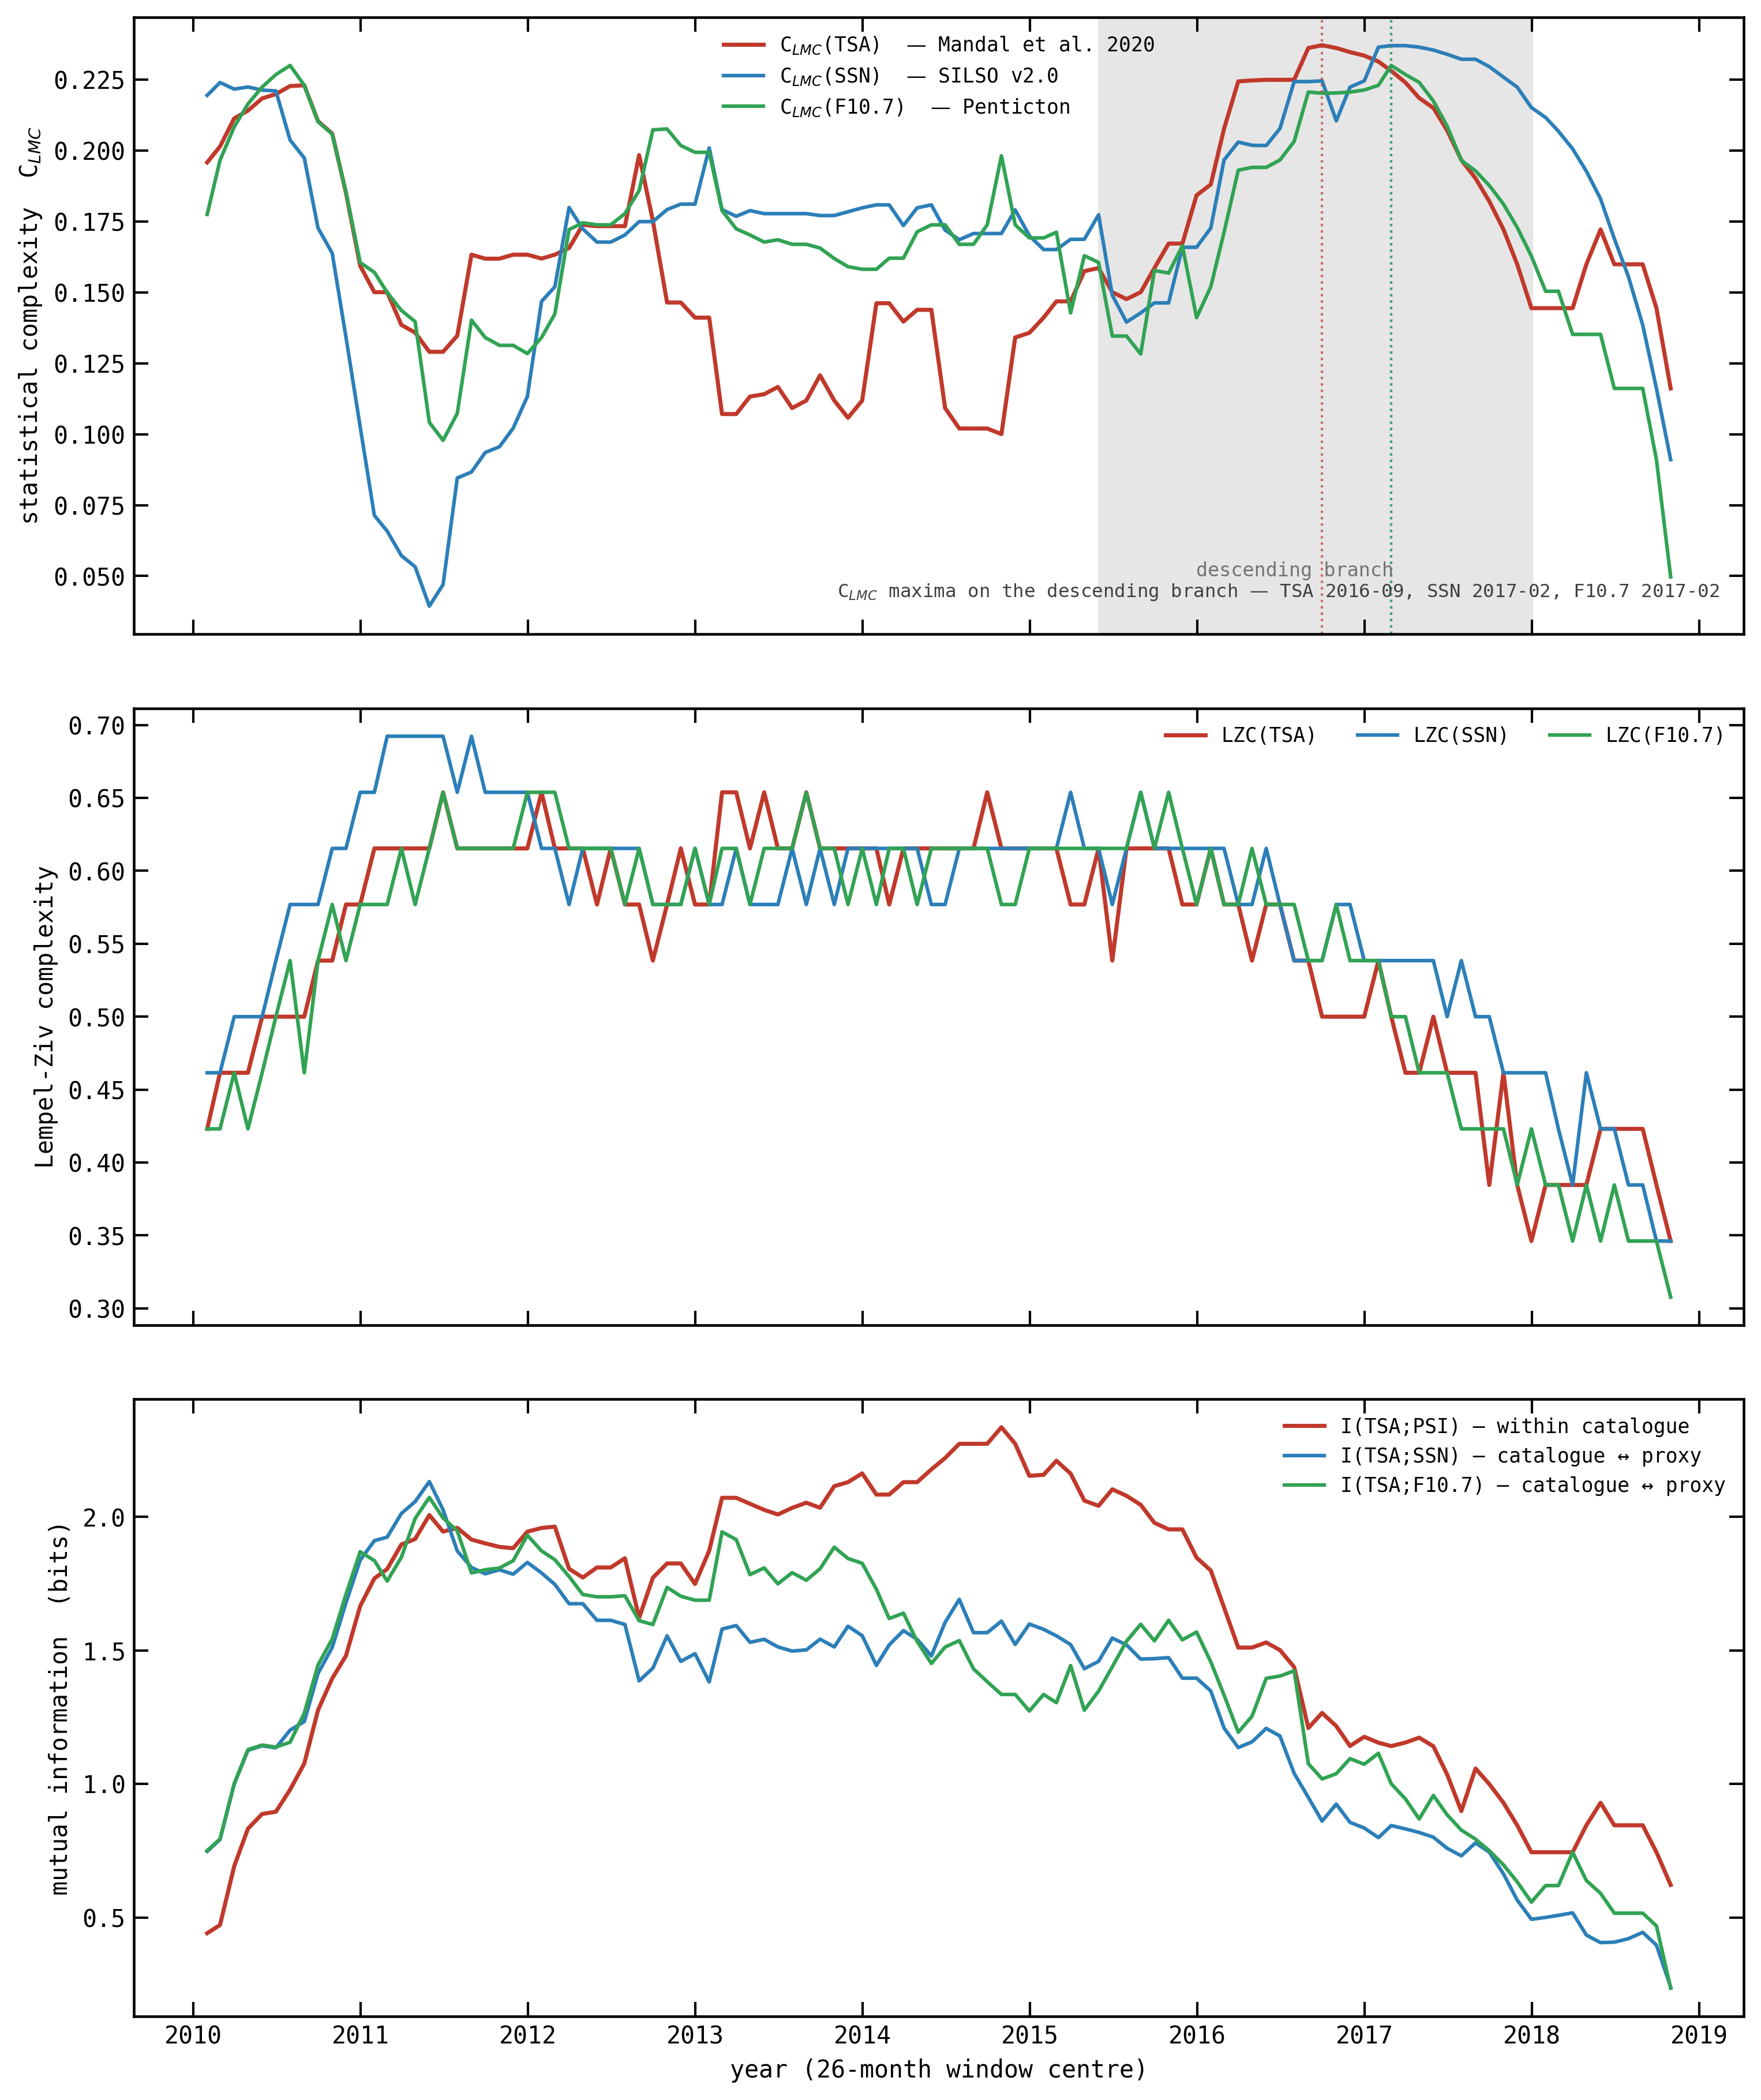

In [15]:
fig, ax = plt.subplots(3, 1, figsize=(12, 15), sharex=True); plt.subplots_adjust(hspace=0.12)
ax[0].plot(swm.index, swm['C_LMC_TSA'], color='#c0392b', lw=1.7, label='C$_{LMC}$(TSA)  — Mandal et al. 2020')
ax[0].plot(swSSN.index, swSSN['C_LMC'], color='#2c7fb8', lw=1.5, label='C$_{LMC}$(SSN)  — SILSO v2.0')
ax[0].plot(swF.index,  swF['C_LMC'],   color='#31a354', lw=1.5, label='C$_{LMC}$(F10.7)  — Penticton')
for d, c in [(swm['C_LMC_TSA'].idxmax(), '#c0392b'), (swSSN['C_LMC'].idxmax(), '#2c7fb8'), (swF['C_LMC'].idxmax(), '#31a354')]:
    ax[0].axvline(d, color=c, ls=':', lw=1, alpha=.7)
ax[0].axvspan(pd.Timestamp('2015-06-01'), pd.Timestamp('2018-01-01'), color='0.9', zorder=0)
ax[0].text(pd.Timestamp('2016-08-01'), 0.05, 'descending branch', ha='center', fontsize=8, color='0.45')
ax[0].set_ylabel('statistical complexity  C$_{LMC}$'); ax[0].legend(loc='upper center', frameon=False, fontsize=8.3)
ax[0].annotate(f"C$_{{LMC}}$ maxima on the descending branch — "
               f"TSA {swm['C_LMC_TSA'].idxmax():%Y-%m}, SSN {swSSN['C_LMC'].idxmax():%Y-%m}, F10.7 {swF['C_LMC'].idxmax():%Y-%m}",
               (0.985, 0.06), xycoords='axes fraction', ha='right', fontsize=7.8, color='0.25')
ax[1].plot(swm.index, swm['LZC_TSA'], color='#c0392b', lw=1.7, label='LZC(TSA)')
ax[1].plot(swSSN.index, swSSN['LZC'], color='#2c7fb8', lw=1.5, label='LZC(SSN)')
ax[1].plot(swF.index,  swF['LZC'],   color='#31a354', lw=1.5, label='LZC(F10.7)')
ax[1].set_ylabel('Lempel-Ziv complexity'); ax[1].legend(loc='upper right', frameon=False, fontsize=8.3, ncol=3)
ax[2].plot(swm.index, swm['MI'], color='#c0392b', lw=1.7, label='I(TSA;PSI) — within catalogue')
ax[2].plot(MI_tsa_ssn.index,  MI_tsa_ssn['plug'],  color='#2c7fb8', lw=1.5, label='I(TSA;SSN) — catalogue ↔ proxy')
ax[2].plot(MI_tsa_f107.index, MI_tsa_f107['plug'], color='#31a354', lw=1.5, label='I(TSA;F10.7) — catalogue ↔ proxy')
ax[2].set_ylabel('mutual information  (bits)'); ax[2].legend(loc='upper right', frameon=False, fontsize=8.3)
ax[2].xaxis.set_major_locator(YearLocator()); ax[2].xaxis.set_major_formatter(DateFormatter('%Y'))
ax[2].set_xlabel('year (26-month window centre)')
fig.savefig('fig_proxy_replication.png', dpi=160, bbox_inches='tight'); plt.show()

### Analysis

The signatures reproduce. The statistical complexity of both proxies peaks on the
descending branch within months of TSA — C$_{LMC}$(SSN) and C$_{LMC}$(F10.7) reach
their maxima in early 2017 against TSA's late-2016 maximum — and, more striking, they
reach almost the same value (≈ 0.23–0.24), so the descending-branch structuring is a
property of the cycle and not of the area catalogue. The Lempel–Ziv complexities of
the three series are nearly indistinguishable across the whole window, high and flat
through the active years and declining together into the minimum, which is the
behaviour the manuscript reports and cites from prior work on LZC as an activity
descriptor. The coupling structure holds at two levels. Within the
catalogue, recomputing I(TSA;PSI) on the retrieved series reproduces the manuscript's
modulation exactly (plug-in 5.3×, Kraskov 1.4×), which certifies that the retrieved
data match the original. Between systems, TSA shares strongly modulated information
with the independent proxies — I(TSA;SSN) and I(TSA;F10.7) modulate by factors of 4.0×
and 2.9× under the bias-free Kraskov estimator — so the coupling the manuscript reads
inside the catalogue is not confined to it; the sunspot-area series and unrelated
activity records rise and fall in shared information together through the cycle. What
does *not* transfer is the specific 23-month hysteresis lag — an internal TSA–PSI
relationship with no exact analogue between separate observables — and it is left out
rather than forced. The honest summary is that the marginal signatures, the
descending-branch complexity maximum, and the coupling are all solar, reproduced on
records that share none of Mandal's instrumentation.

## Provenance and reproducibility

`seed = 20260531` throughout. Proxy inputs: SILSO SSN v2.0 (monthly and daily) and
Penticton F10.7 noon values, aggregated to the 2008-12 → 2019-10 window and written to
`data/proxies_monthly.csv` and `data/proxies_daily.csv`; F10.7 uses the observed (not
distance-adjusted) flux, a choice that leaves the cycle-scale structure intact. §1
reads only the repository's `sliding_window_metrics.csv`. Figures are written beside
this notebook as `fig_phase_lag.png`, `fig_mpr_plane.png`, `fig_proxy_replication.png`
with no embedded titles, for direct use with a separate caption. The raw TSA and PSI
series were retrieved from VizieR (J/A+A/640/A78) with `fetch_tsa_psi.py` into
`data/sc24_daily.csv` and `data/sc24_monthly.csv`; that they reproduce the manuscript's
Table II permutation entropies and its I(TSA;PSI) modulation confirms the retrieval.
All three contributions now run to completion with no external dependency beyond the
two proxy records and the catalogue series themselves.